<center><h1><strong>Boosting (Adaboost & XgBoost) </strong></h1></center>

Boosting is an ensemble learning technique used in machine learning to improve the performance of weak models.

Instead of using one strong model, boosting combines multiple weak learners to create a strong predictive model.

Weak learner is a model that performs only slightly better than random guessing

Example of weak model:
- Decision stums (trees with depth = 1 )
- Small decision trees

<strong>Why boosting is needed?</strong>
Single machine learning models sometimes:

- Make mistakes
- Underfit the data
- Fail to capture complex patterns

Boosting solve this by:

- Train multiple models
- Focusing more on difficult data points
- Combining predictions to improve accracy

This results in high performance models.

<strong>Boosting widely used in:</strong>

- Credit score
- Fraud Detection
- Recommendation systems
- Kaggle competitions

<h2>Real life example:</h2>

Example : Medical diagnosis

Imagine a doctor diagnosing a disease.

Frist doctor:
- makes some mistakes

Second doctor:
- Looks carefully at the cases where the first doctor failed.

Third doctor:
- focuses on the hardest cases.

Finally, they combine their knowledge to make a better diagnosis.

this exactly how bossting works.

<h2>How boosting works </h2>

Step 01: train weak model<br>
Step 02: identify the errors made by that model<br>
Step 03: Increase Imporatnce (weight) of misclassified points<br>
Step 04: Train another model focusing more on those difficult samples<br>
Step 05: Repeat this process multiple times.<br>
Step 06: Combine predictions of all models.<br>

final prediction is made using weighted voting.

<h2><strong>Adaboost algorithm</strong></h2>

Adaboost Stands for:

<strong>Adaptive Boosting</strong>

It was the first successful boosting algorithm.

Adaboost works by:
- Assigning equal wieghts to all training samples.
- Training a weak learner
- Increasing weights for misclassified samples.
- Training another learner focusing more on mistakes

<h3>Adaboos workflows:</h3>

Step 01: Initialize weights for all training samples.<br>
Step 02: Train a weak classifier<br>
Step 03: Calcualte error rate.<br>
Step 04: Increase weight of misclassified points<br>
Step 05: Train next classifier<br>
Step 06: Combine models using weighted voting.<br>


Misclassified points become more important in the next iteration.

In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
data = load_breast_cancer()

X = data.data
y = data.target


In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

Create the base model

In [7]:
base_model = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
        estimator = base_model,
        n_estimators = 50,
        learning_rate = 1
)

In [8]:
model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [9]:
pred = model.predict(X_test)

In [11]:
print("Accuracy: ",accuracy_score(y_test,pred))

Accuracy:  1.0


In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons


In [13]:
X,y = make_moons(n_samples=500,noise=0.3, random_state=42)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
def plot_decision_boundary(model,X,y):
    x_min,x_max = X[:,0].min()-1,X[:,0].max()+1
    y_min,y_max = X[:,1].min()-1,X[:,1].max()+1

    xx,yy = np.meshgrid(
        np.arange(x_min,x_max,0.02),
        np.arange(y_min,y_max,0.02)
    )

    z = model.predict(np.c_[xx.ravel(),yy.ravel()])
    z = z.reshape(xx.shape)

    plt.contourf(xx,yy,z,alpha=0.3)
    plt.scatter(X[:,0],X[:,1],c=y)
    plt.show()

0.89


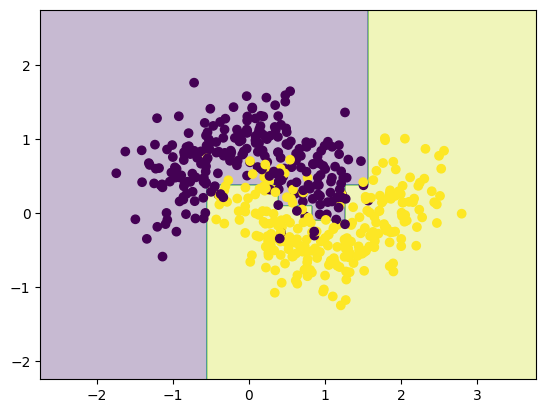

In [21]:
import numpy as np

base_model = DecisionTreeClassifier(max_depth=1)
model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate = 1
)

model.fit(X_train,y_train)
pred = model.predict(X_test)
print(accuracy_score(y_test,pred))
plot_decision_boundary(model,X,y)

0.9


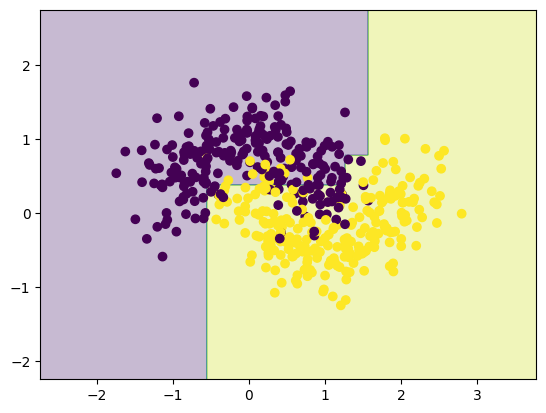

In [22]:

base_model = DecisionTreeClassifier(max_depth=1)
model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=10,
    learning_rate = 1
)

model.fit(X_train,y_train)

pred = model.predict(X_test)
print(accuracy_score(y_test,pred))
plot_decision_boundary(model,X,y)

0.71


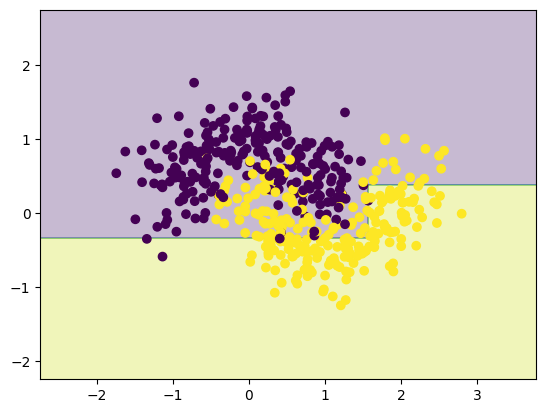

In [25]:

base_model = DecisionTreeClassifier(max_depth=1)
model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=200,
    learning_rate = 2
)

model.fit(X_train,y_train)

pred = model.predict(X_test)
print(accuracy_score(y_test,pred))
plot_decision_boundary(model,X,y)

0.88


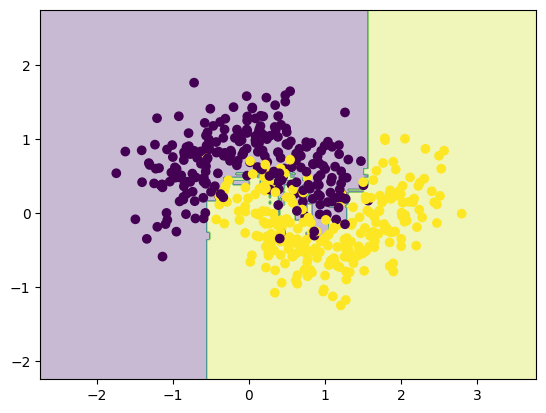

In [26]:

base_model = DecisionTreeClassifier(max_depth=3)
model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate = 1
)

model.fit(X_train,y_train)

pred = model.predict(X_test)
print(accuracy_score(y_test,pred))
plot_decision_boundary(model,X,y)